In [133]:
# =========================
# 0) IMPORTS Y CONFIGURACIÓN
# =========================
# Importamos librerías básicas y Keras/TensorFlow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Configuración estética para gráficas
sns.set(font_scale=1.2)
plt.style.use('seaborn-v0_8-darkgrid')

# Fijamos una semilla para reproducibilidad (opcional)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías cargadas correctamente. TensorFlow version:', tf.__version__)


Librerías cargadas correctamente. TensorFlow version: 2.19.0


In [134]:
# ============================================
# 1) CARGA Y PREPROCESAMIENTO DEL DATASET MNIST
# ============================================
# Cargamos MNIST (imágenes 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizamos los pixeles a rango [0,1] y convertimos a float32
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Añadimos el canal de profundidad (1) → shape (N,28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Convertimos etiquetas a one-hot para clasificación con las CNNs
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)
print('  y_train (categorical):', y_train_cat.shape)
print('  y_test (categorical):', y_test_cat.shape)


Shapes:
  X_train: (60000, 28, 28, 1)
  X_test : (10000, 28, 28, 1)
  y_train (categorical): (60000, 10)
  y_test (categorical): (10000, 10)


In [135]:
# ============================================
# 2) DEFINICIÓN DE MODELO CNN
# ============================================

# MODELO CNN Profunda (2 conv + pool, luego otras 2 conv + pool)
inputs2 = Input(shape=(28,28,1), name='input_profundo')
# Bloque 1: 2 convoluciones seguidas y pooling
x2 = Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1')(inputs2)
x2 = Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_1')(x2)
# Bloque 2: otras 2 convoluciones y pooling
x2 = Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_3')(x2)
x2 = Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_4')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_2')(x2)
# Final
x2 = Flatten(name='flatten')(x2)
x2 = Dense(256, activation='relu', name='dense_256')(x2)
outputs2 = Dense(10, activation='softmax', name='output')(x2)

cnn_profundo = Model(inputs2, outputs2, name='CNN_Profundo')
cnn_profundo.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nModelo creado CNN Profundo')



Modelo creado CNN Profundo


In [136]:
# Mostrar resúmenes (arquitectura y parámetros)
print('\n--- Resumen: CNN Profundo ---')
cnn_profundo.summary()


--- Resumen: CNN Profundo ---


Model: "CNN_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_profundo (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,930 (13.74 MB)

 Trainable params: 3,601,930 (13.74 MB)

 Non-trainable params: 0 (0.00 B)

In [137]:
# ============================================
# 3) ENTRENAMIENTO
# ============================================
epochs = 50        # Ajusta según recurso (Colab GPU: sube si quieres)
batch_size = 128

# Entrenamos la CNN profunda (mismas condiciones)
history_profundo = cnn_profundo.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.8933 - loss: 0.3376 - val_accuracy: 0.9878 - val_loss: 0.0442
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9883 - val_loss: 0.0422
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9950 - loss: 0.0168 - val_accuracy: 0.9887 - val_loss: 0.0483
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9902 - val_loss: 0.0354
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9912 - val_loss: 0.0390
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9973 - loss: 0.0080 - val_accuracy: 0.9905 - val_loss: 0.0523
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9972 - loss: 0.0069 - val_acc

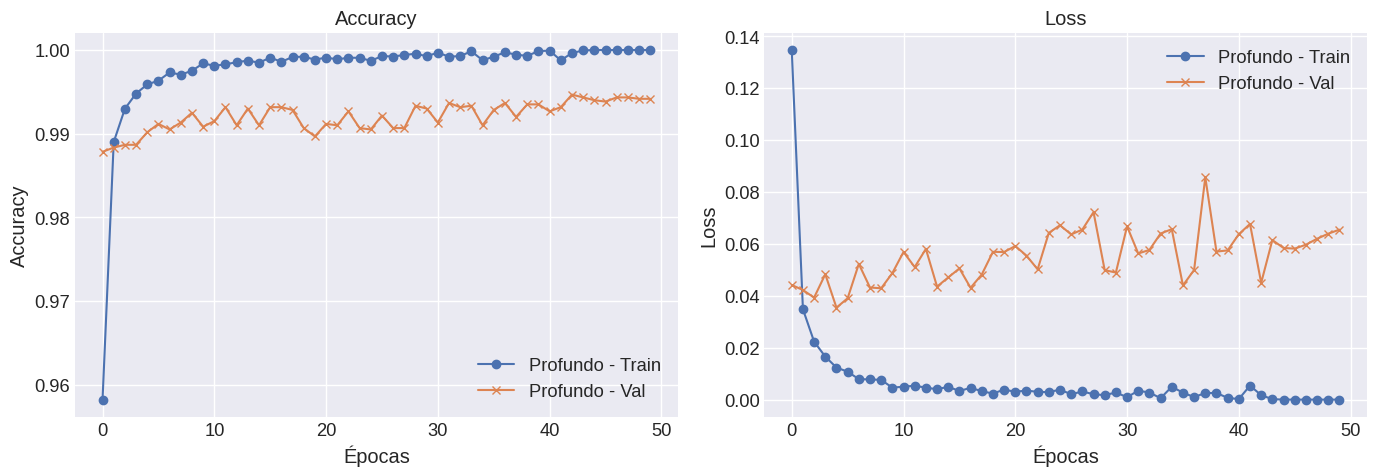

In [138]:
# ============================================
# 4) COMPARACIÓN VISUAL: Accuracy y Loss
# ============================================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_profundo.history['accuracy'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_accuracy'], marker='x', label='Profundo - Val')
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_profundo.history['loss'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_loss'], marker='x', label='Profundo - Val')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



=== CNN Profundo: 4 capas convolucionales detectadas ===

Procesando capa: conv2d_1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


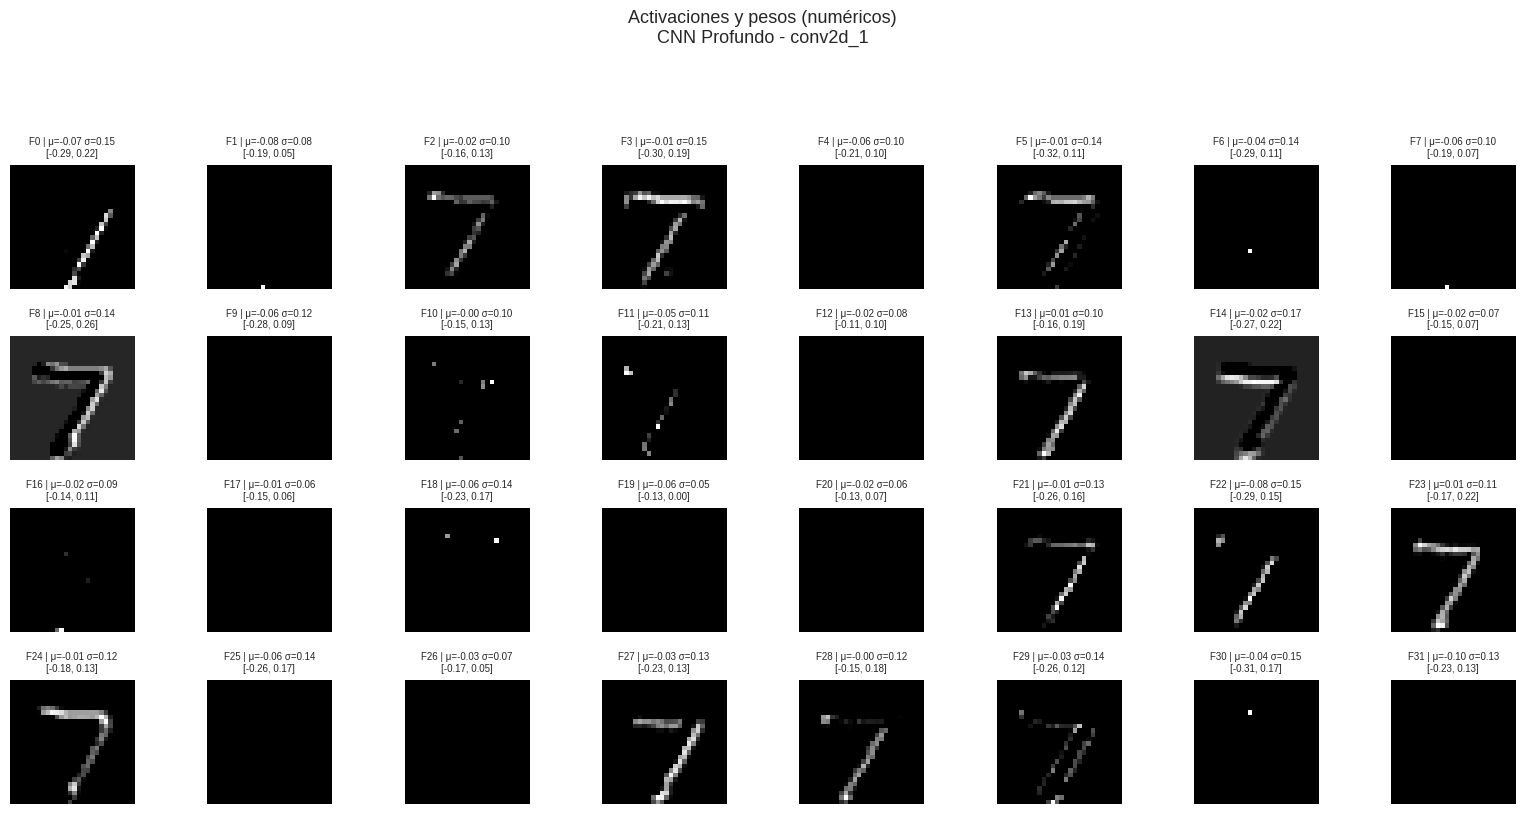

Procesando capa: conv2d_2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


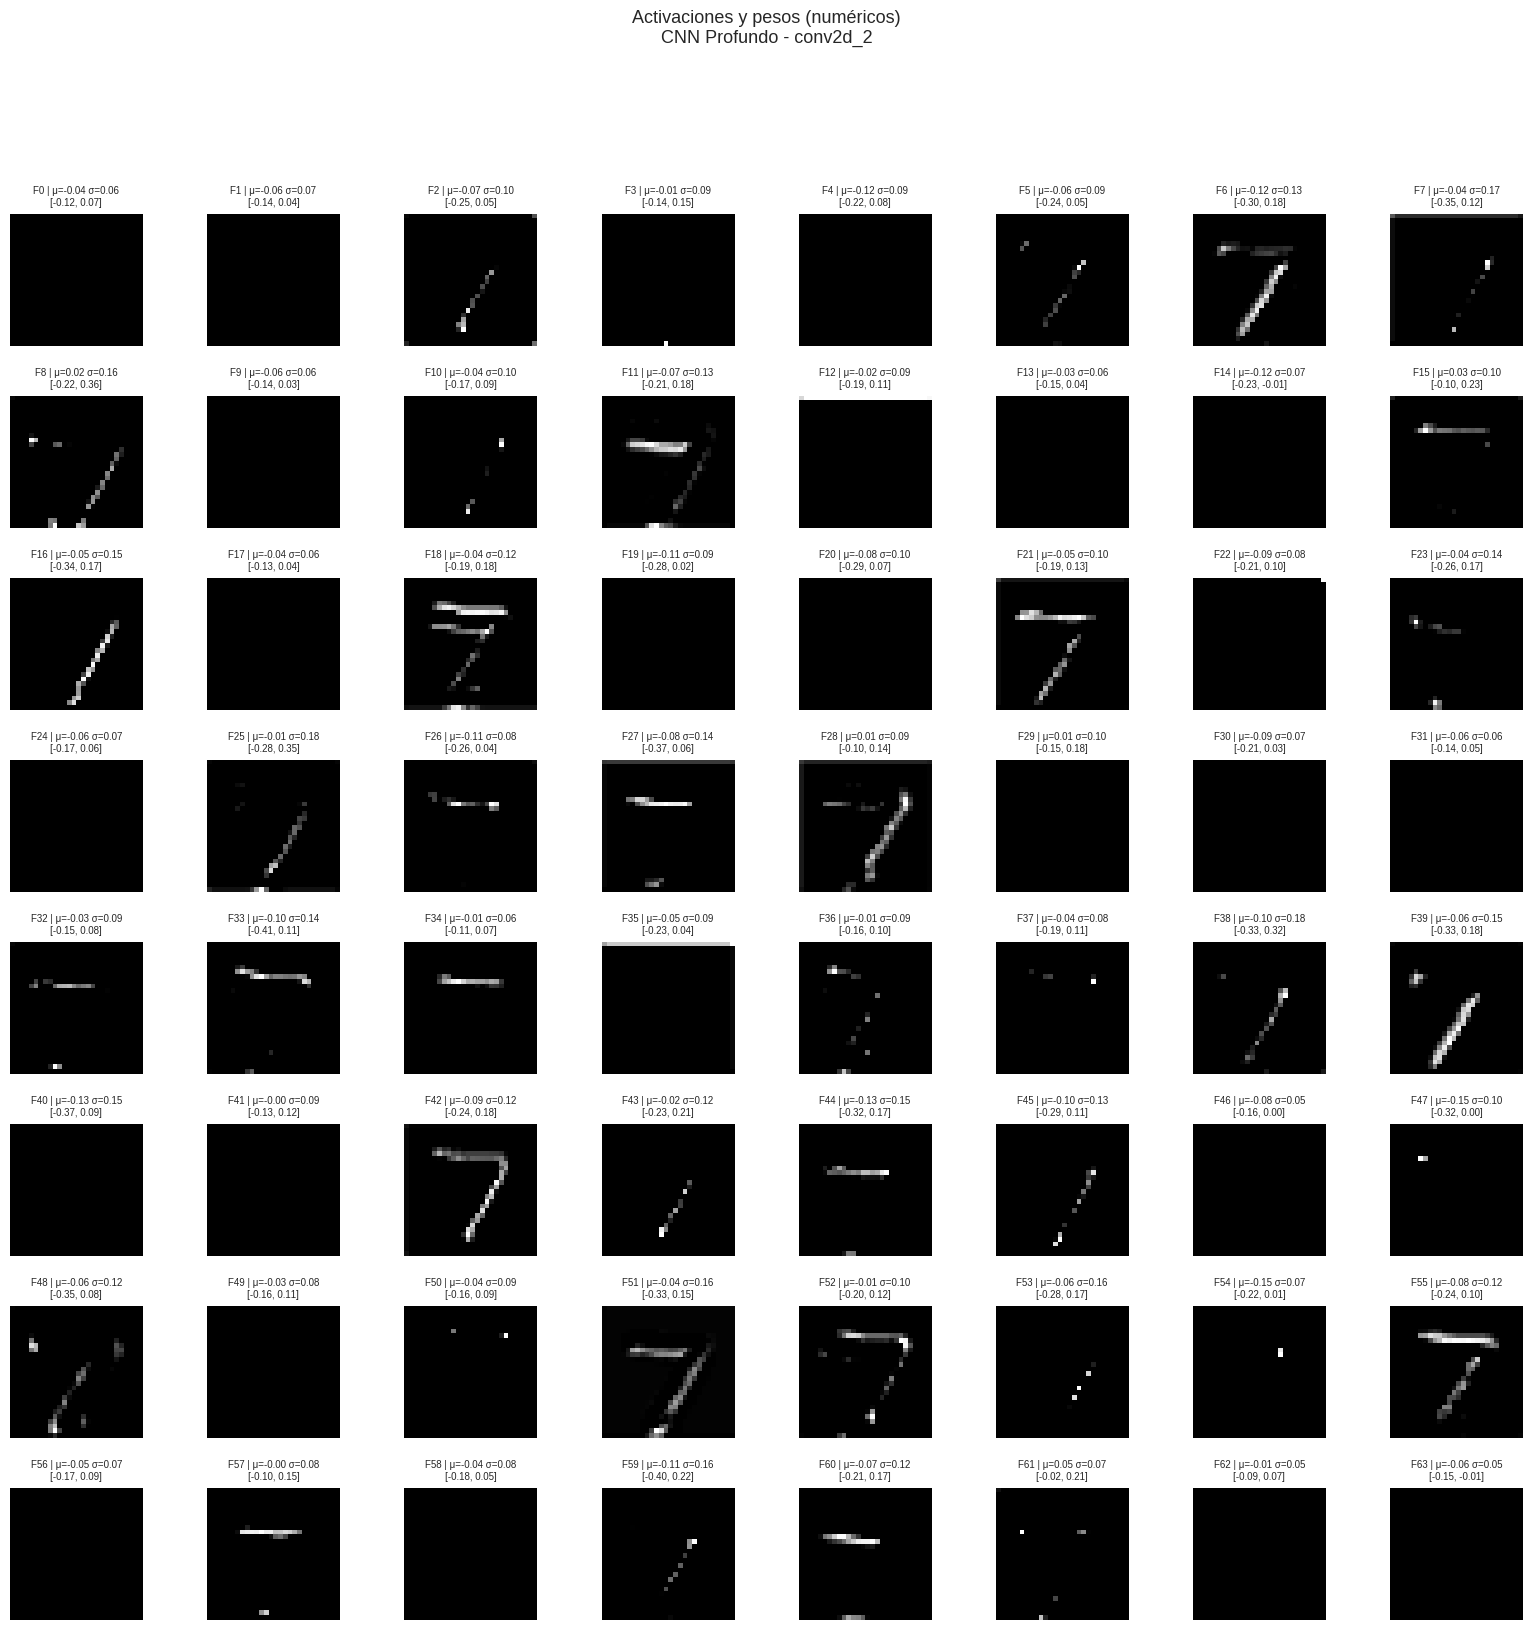

Procesando capa: conv2d_3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


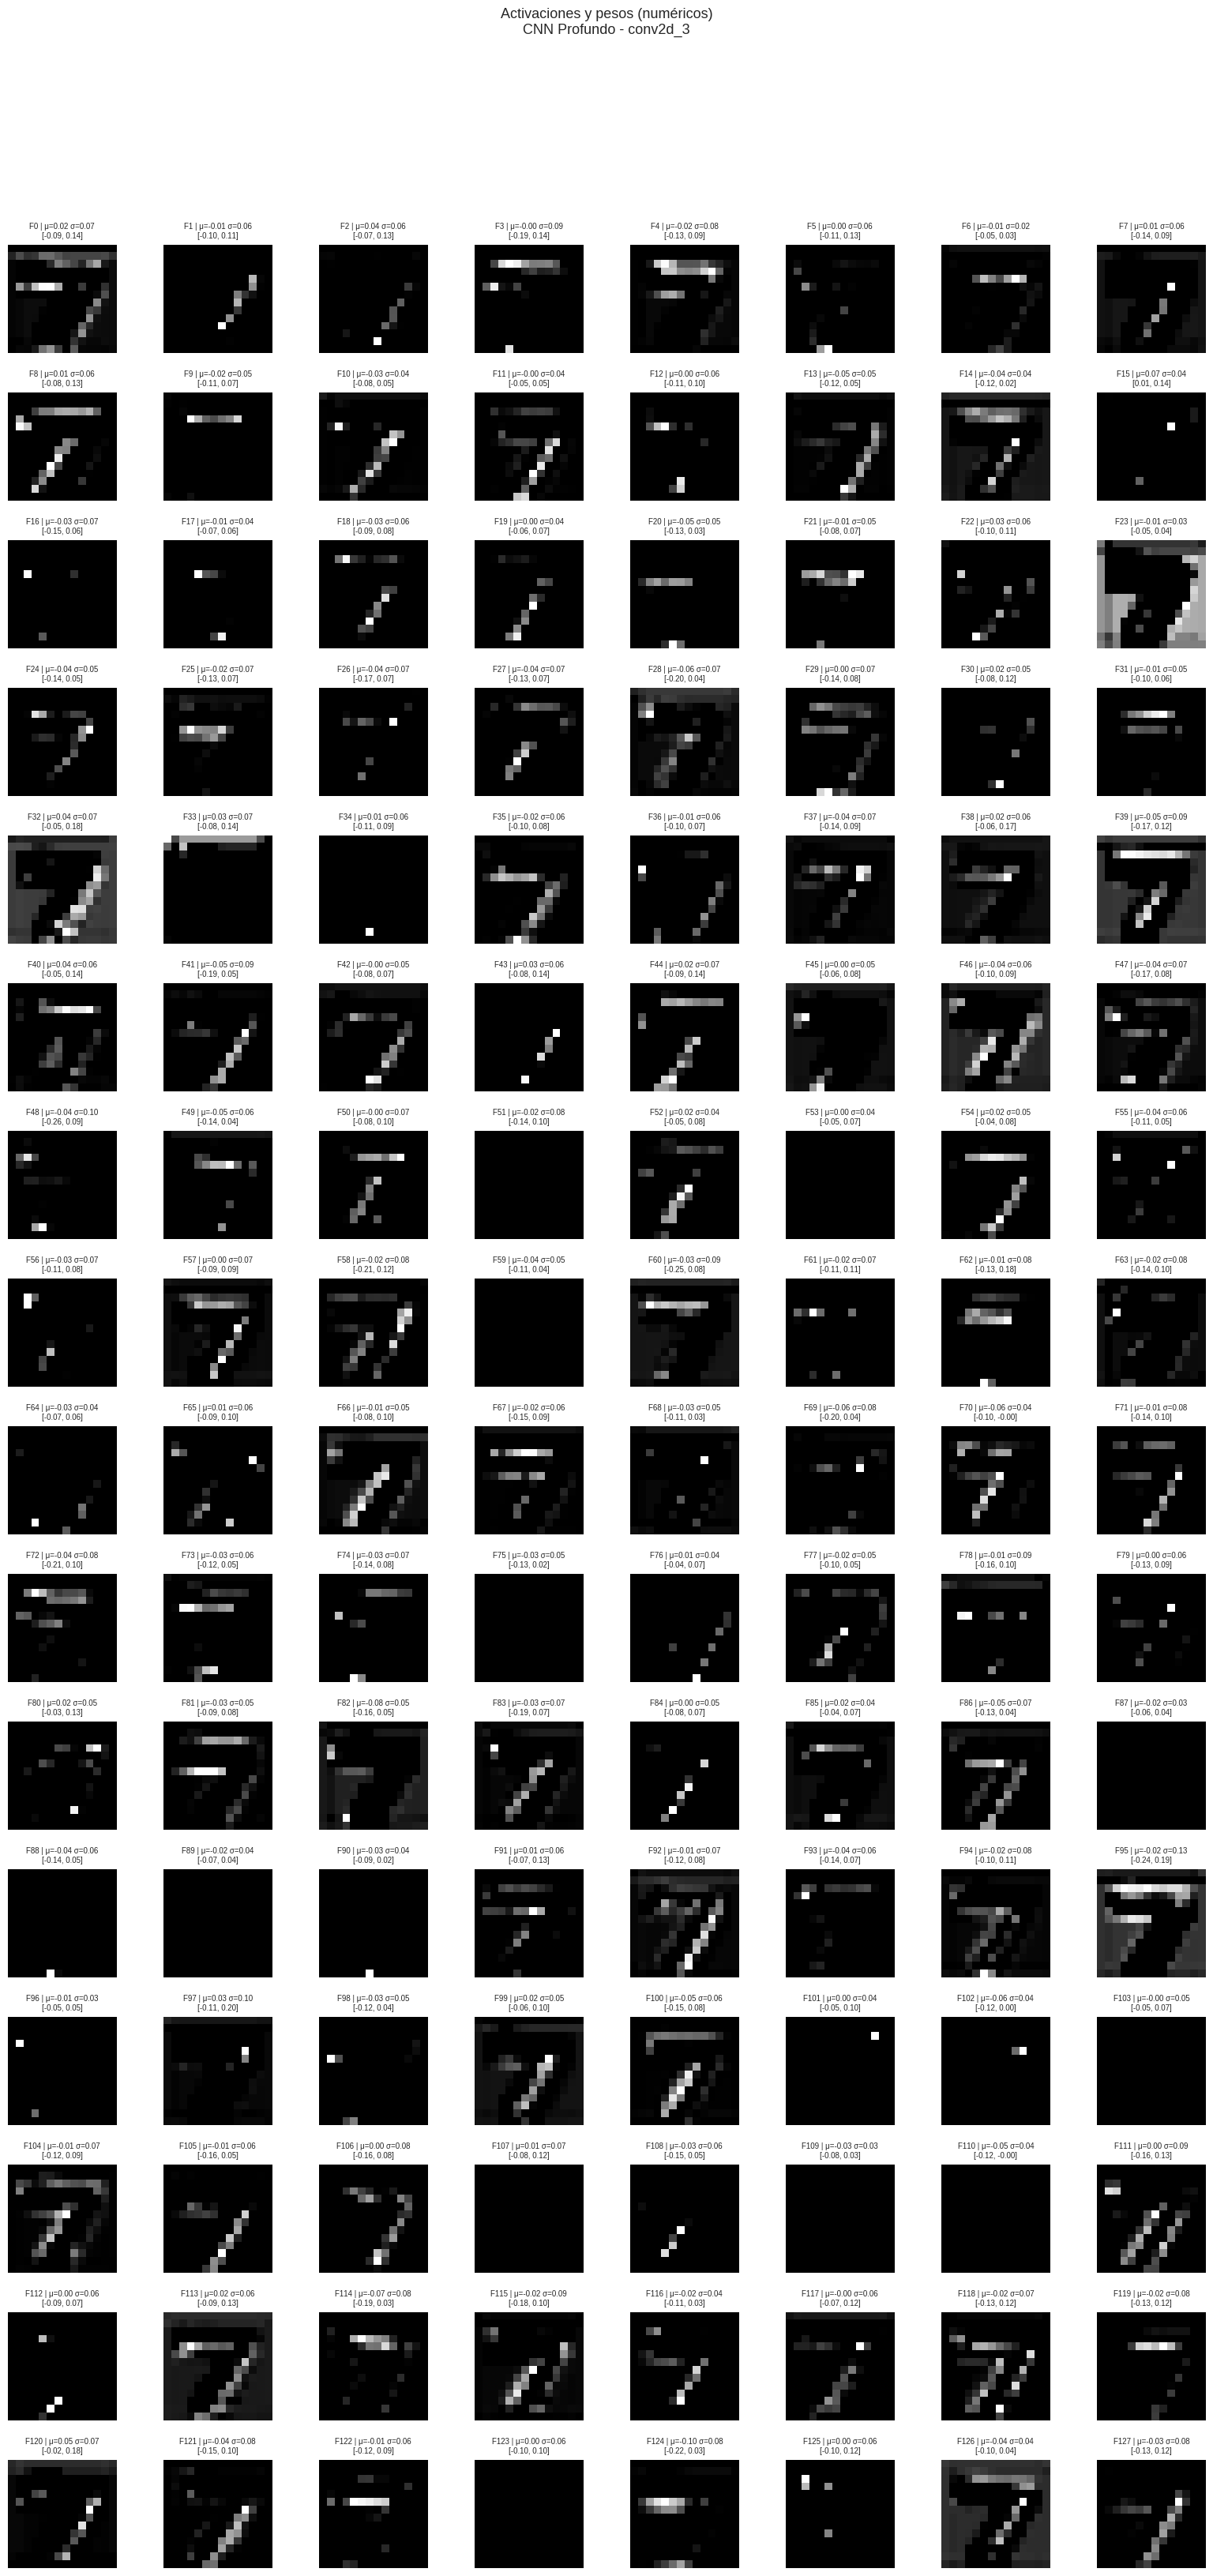

Procesando capa: conv2d_4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step


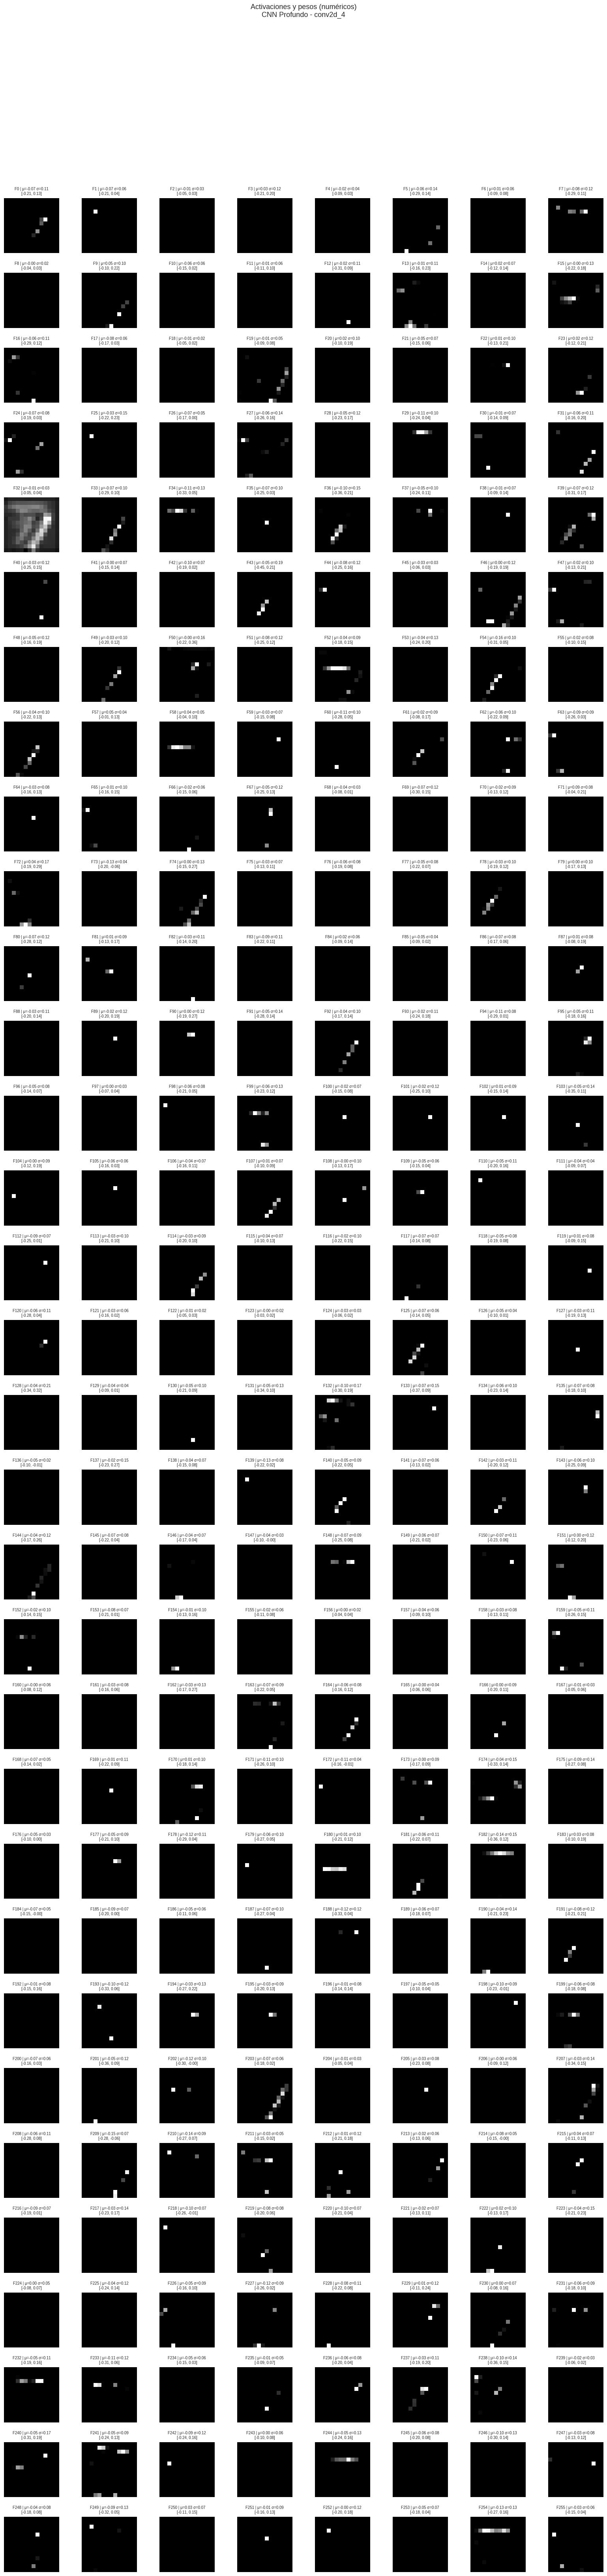

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import mnist
import numpy as np

# Cargar datos MNIST
(_, _), (x_test, _) = mnist.load_data()

# Seleccionar una imagen de prueba y darle forma correcta
base_img = x_test[0].astype('float32') / 255.0
base_img = np.expand_dims(base_img, axis=-1)  # Añadir canal (28,28,1)


def plot_conv_filters(model, img, layer_name, model_name="CNN"):

    if img.ndim == 3:
        img = img[np.newaxis, ...]

    layer = model.get_layer(layer_name)
    weights, biases = layer.get_weights()
    act_model = Model(inputs=model.input, outputs=layer.output)
    activations = act_model.predict(img)[0]

    n_filters = activations.shape[-1]
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_filters):
        kernel = weights[:, :, 0, i]
        mean_w = np.mean(kernel)
        std_w = np.std(kernel)
        min_w = np.min(kernel)
        max_w = np.max(kernel)

        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activations[:, :, i], cmap='gray')
        plt.axis('off')
        plt.title(f"F{i} | μ={mean_w:.2f} σ={std_w:.2f}\n[{min_w:.2f}, {max_w:.2f}]", fontsize=7)

    # --- Ajuste del espaciado del título ---
    plt.suptitle(f"Activaciones y pesos (numéricos)\n{model_name} - {layer_name}", fontsize=13, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_all_conv_layers(model, img, model_name="CNN"):
    """
    Muestra las activaciones y pesos numéricos de todas las capas Conv2D de un modelo.
    """
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    if not conv_layers:
        print(f"{model_name}: No se encontraron capas convolucionales.")
        return

    print(f"\n=== {model_name}: {len(conv_layers)} capas convolucionales detectadas ===\n")
    for lname in conv_layers:
        print(f"Procesando capa: {lname}")
        plot_conv_filters(model, img, lname, model_name)


# --- Uso ---
plot_all_conv_layers(cnn_profundo, base_img, "CNN Profundo")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


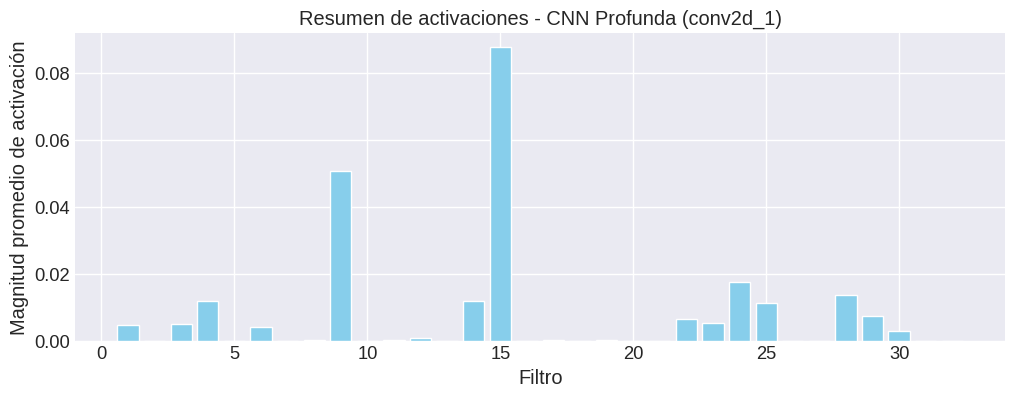

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


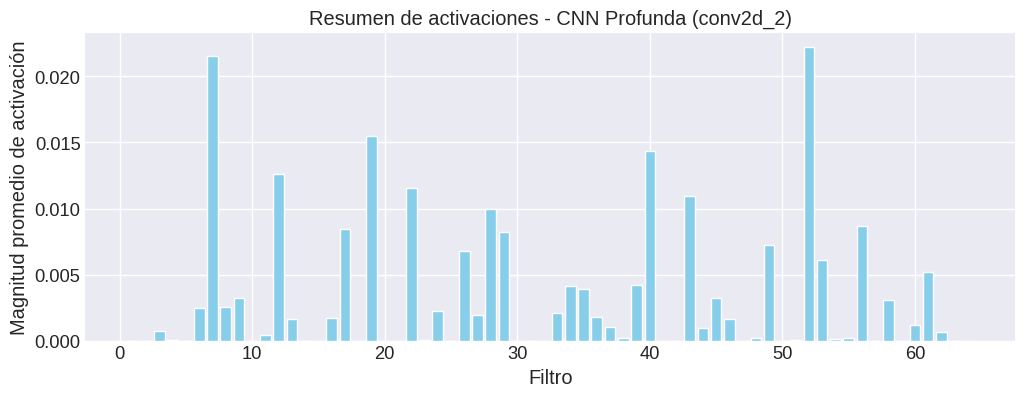

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


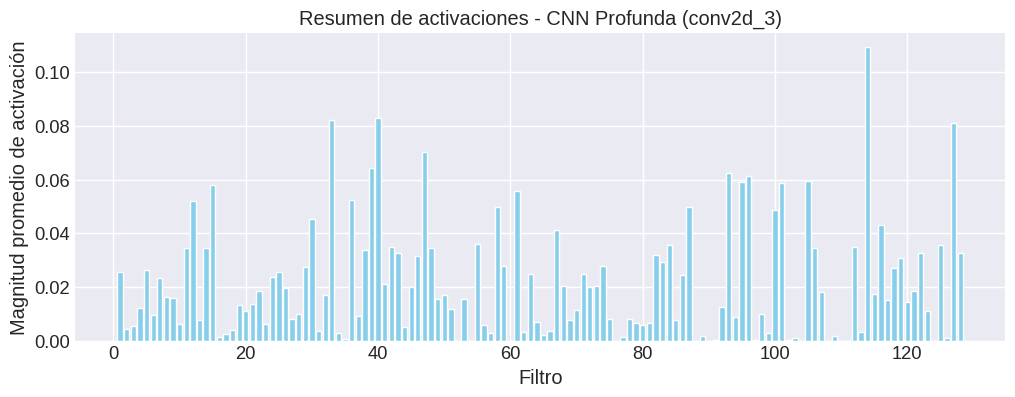

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step


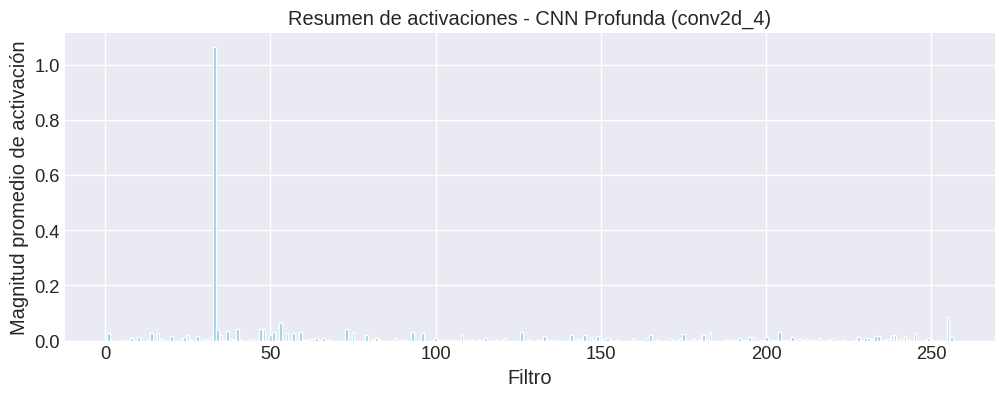

In [140]:
def plot_activation_summary(model, img, layer_name, model_name="CNN"):
    from tensorflow.keras.models import Model
    import matplotlib.pyplot as plt
    import numpy as np

    # Aseguramos batch
    if img.ndim == 3:
        img = img.reshape(1, *img.shape)

    # Modelo intermedio para activaciones
    conv_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    activations = conv_model.predict(img)  # shape: (1,H,W,C)

    # Promedio absoluto de activaciones por filtro
    avg_activations = np.mean(np.abs(activations), axis=(1,2))  # shape: (1,C)
    avg_activations = avg_activations.flatten()

    # Gráfica
    plt.figure(figsize=(12,4))
    plt.bar(range(1, len(avg_activations)+1), avg_activations, color='skyblue')
    plt.xlabel("Filtro")
    plt.ylabel("Magnitud promedio de activación")
    plt.title(f"Resumen de activaciones - {model_name} ({layer_name})")
    plt.show()

plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_1", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_2", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_3", model_name="CNN Profunda")
plot_activation_summary(cnn_profundo, base_img, layer_name="conv2d_4", model_name="CNN Profunda")


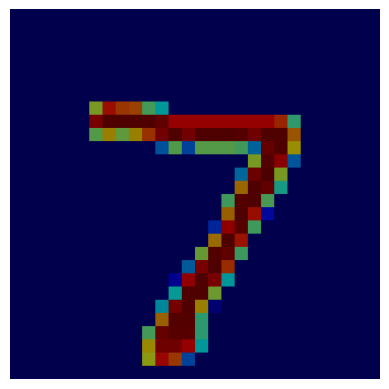

In [146]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def prepare_image(img):
    if img.ndim == 2:
        img = np.expand_dims(img, axis=-1)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)
    return img

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name, pred_index=None, gamma=0.5):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))
    conv_outputs = conv_outputs[0]
    weights = weights[0]
    heatmap = tf.reduce_sum(conv_outputs * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap.numpy()

    # Redimensionar heatmap a tamaño original de la imagen
    heatmap = cv2.resize(heatmap, (img_tensor.shape[2], img_tensor.shape[1]), interpolation=cv2.INTER_LINEAR)

    # Aplicar máscara del dígito
    mask = np.squeeze(img_tensor)
    if mask.ndim == 3:
        mask = mask[...,0]
    heatmap *= mask

    # Normalizar usando min-max
    eps = 1e-8
    heatmap = (heatmap - np.min(heatmap)) / max(np.max(heatmap) - np.min(heatmap), eps)

    # Ajuste gamma
    heatmap = heatmap ** gamma

    return heatmap


def superimpose_heatmap(img, heatmap, alpha=0.5, scale_up=10):
    img_gray = np.squeeze(img)
    if img_gray.ndim == 3:
        img_gray = img_gray[...,0]
    img_gray = (img_gray * 255).astype(np.uint8)
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    # Redimensionar heatmap a tamaño original
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Mezclar con la imagen original
    superimposed_img = cv2.addWeighted(heatmap_color, alpha, img_rgb, 1-alpha, 0)

    # Ampliar para visualizar mejor
    superimposed_img = cv2.resize(superimposed_img,
                                  (img_rgb.shape[1]*scale_up, img_rgb.shape[0]*scale_up),
                                  interpolation=cv2.INTER_NEAREST)
    return superimposed_img

# -----------------------
# Uso
# -----------------------
base_img_tensor = prepare_image(base_img)  # base_img = (28,28)
last_conv_layer_name = "conv2d_4"
heatmap = make_gradcam_heatmap(base_img_tensor, cnn_profundo, last_conv_layer_name)
superimposed_img = superimpose_heatmap(base_img_tensor[0], heatmap, alpha=0.6)

plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
